# ¿Podemos estimar el radio de un exoplaneta a partir de su masa?

Usaremos **PSCompPars**, una tabla del [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/) con una fila por planeta. Compararemos una predicción basada en la masa con otra que también considera la **insolación**: el flujo de energía que recibe el planeta por unidad de área, expresado respecto al que llega a la Tierra desde el Sol.

**Pregunta:** dada la masa de un planeta, ¿podemos estimar su radio? ¿Mejora la predicción al añadir la insolación?

Entrenaremos con planetas detectados por tránsito y evaluaremos en planetas reservados al azar. Como la división se hace por planeta, miembros de un mismo sistema estelar pueden quedar en ambos conjuntos. La tabla combina valores de distintas publicaciones y cambia con el tiempo; por eso la muestra y los resultados pueden variar entre ejecuciones.

In [3]:
# NumPy crea y ordena los valores para las gráficas.
import numpy as np
# pandas lee la consulta y organiza los planetas como tabla.
import pandas as pd

# Matplotlib dibuja las gráficas; display presenta tablas legibles.
import matplotlib.pyplot as plt
from IPython.display import display

# quote codifica la consulta para incluirla en la dirección web del Archivo.
from urllib.parse import quote

# scikit-learn separa planetas, ajusta regresores y evalúa predicciones.
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

## Consultar y conocer los datos

La consulta pide solo las columnas necesarias para identificar los planetas, definir la muestra y comparar masa, insolación y radio. En ADQL, **SELECT** elige las columnas y **FROM** indica la tabla. [Guía de consultas TAP de NASA](https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html).

In [4]:
# SELECT elige los campos; FROM indica la tabla del Archivo.
consulta_adql = """
SELECT pl_name, hostname, tran_flag, pl_controv_flag,
       pl_bmasse, pl_bmassprov, pl_bmasse_reflink, pl_bmasselim,
       pl_insol, pl_insollim,
       pl_rade, pl_rade_reflink, pl_radelim
FROM pscomppars
""".strip()

# TAP devuelve un CSV; pandas lo convierte en una tabla de trabajo.
url_tap = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query="
    + quote(consulta_adql)
    + "&format=csv"
)
datos_crudos = pd.read_csv(url_tap)

print(f"Tabla recibida: {datos_crudos.shape[0]:,} filas y {datos_crudos.shape[1]} columnas")
display(datos_crudos[["pl_name", "pl_bmasse", "pl_insol", "pl_rade"]].head())
display(datos_crudos[["pl_bmasse", "pl_insol", "pl_rade"]].describe().T)

Tabla recibida: 6,372 filas y 13 columnas


,pl_name,pl_bmasse,pl_insol,pl_rade
0,HD 2039 b,1999.1507,0.3229,12.700000
1,HAT-P-8 b,406.8224,1519.9645,15.692600
2,K2-43 b,18.5000,49.0000,4.510000
3,Kepler-1753 b,5.5900,27.4100,2.226781
4,Kepler-1176 b,6.5700,26.0870,2.450000


,count,mean,std,min,25%,50%,75%,max
pl_bmasse,6341.0,405.836454,1139.048466,0.0200,4.320000,9.40000,194.829790,9534.85221
pl_insol,5780.0,534.879697,9926.573366,0.0000,10.043075,65.86245,280.843500,636352.12580
pl_rade,6322.0,5.879704,5.428941,0.3098,1.850000,2.87000,11.992707,87.20587


### ¿Qué significa cada columna?

Las columnas describen los planetas, documentan cómo se obtuvieron algunas cantidades y permiten filtrar la muestra. Solo **masa**, **insolación** y **radio** entran en el análisis numérico: masa e insolación son predictores; radio es el valor que intentamos estimar.

| Columna | Significado y uso en esta actividad |
| --- | --- |
| **pl_name** | Nombre del planeta; permite reconocer las filas. |
| **hostname** | Nombre de la estrella anfitriona; agrupa sus planetas al separar entrenamiento y prueba. No es predictor. |
| **tran_flag** | Indicador de detección por tránsito: 1 significa que el planeta transita su estrella. |
| **pl_controv_flag** | Indicador de controversia en la confirmación: 0 significa que no está marcado como controvertido. |
| **pl_bmasse** | Mejor estimación disponible de masa, en masas terrestres. Según su procedencia puede representar masa, masa proyectada corregida por inclinación o el producto masa por seno de la inclinación. |
| **pl_bmassprov** | Procedencia del valor de masa. Conservamos **Mass** para usar masas reportadas como tales. |
| **pl_bmasse_reflink** | Referencia del valor de masa. **Calculated Value** identifica un valor calculado por el Archivo. |
| **pl_bmasselim** | Indicador de límite de la masa. 0 señala un valor central; otros valores señalan un límite; vacío significa que el estado no está informado. |
| **pl_insol** | Flujo de insolación recibido, en unidades del flujo que recibe la Tierra del Sol. |
| **pl_insollim** | Indicador de si la insolación es un valor central o un límite; vacío significa que el estado no está informado. |
| **pl_rade** | Radio planetario, en radios terrestres. Es el objetivo que predecimos. |
| **pl_rade_reflink** | Referencia del radio. **Calculated Value** puede indicar que el Archivo lo derivó de la masa. |
| **pl_radelim** | Indicador de si el radio es un valor central o un límite; vacío significa que el estado no está informado. |

NASA mantiene las [definiciones de las columnas](https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html) y explica los [cálculos de PSCompPars](https://exoplanetarchive.ipac.caltech.edu/docs/pscp_calc.html).

### Preparar una muestra comparable

El filtro define qué planetas entran en la comparación. Conservamos los detectados por tránsito, no marcados como controvertidos, con masa de procedencia **Mass**, y con valores centrales de masa, insolación y radio.

El Archivo puede calcular el radio a partir de la masa y la masa a partir del radio. Excluir esos valores calculados evita que el objetivo y el predictor compartan una relación construida de antemano. Conservamos la insolación calculada: NASA puede derivarla de la luminosidad de la estrella y la distancia orbital, sin usar el radio.

Eliminamos filas sin masa, insolación, radio o estrella anfitriona, y valores no positivos. Así el modelo recibe datos completos y el gráfico masa-radio puede usar ejes logarítmicos. No descargamos incertidumbres porque este ejercicio no las incorpora al ajuste.

In [5]:
datos = datos_crudos.copy()

# Filtramos referencias de masa válidas:
# - .notna(): verifica que el valor no sea nulo (NaN), es decir, que sí exista una referencia.
# - .str.contains("Calculated Value", case=False, na=False): busca si el texto incluye "Calculated Value"
#   (case=False ignora mayúsculas/minúsculas y na=False evita errores si hay valores faltantes).
# - El símbolo ~ invierte la condición (negación), para excluir los valores calculados.
valido_masa = (
    datos["pl_bmasse_reflink"].notna()
    & ~datos["pl_bmasse_reflink"].str.contains("Calculated Value", case=False, na=False)
)

# Aplicamos la misma lógica para el radio:
valido_radio = (
    datos["pl_rade_reflink"].notna()
    & ~datos["pl_rade_reflink"].str.contains("Calculated Value", case=False, na=False)
)

# Conservamos solo aquellos planetas donde tanto masa como radio tienen referencias publicadas
referencias_publicadas = valido_masa & valido_radio


# Una bandera igual a cero indica que la cantidad no está expresada como límite (es un valor medido/central).
columnas_limite = ["pl_bmasselim", "pl_insollim", "pl_radelim"]

valores_centrales = (datos[columnas_limite] == 0).all(axis=1)


seleccion = (
    datos["tran_flag"].eq(1)             # Solo planetas en tránsito (radio confiable)
    & datos["pl_controv_flag"].eq(0)     # Excluir planetas controvertidos
    & datos["pl_bmassprov"].eq("Mass")   # Masa real confirmada (no masa mínima M*sin(i))
    & referencias_publicadas             # Con literatura revisada
    & valores_centrales                  # Sin límites superiores/inferiores
)


# hostname se conserva solo para separar sistemas; no entra entre los predictores.
columnas_modelo = ["pl_bmasse", "pl_insol", "pl_rade", "hostname"]
columnas_numericas = ["pl_bmasse", "pl_insol", "pl_rade"]

# Conservamos filas completas y valores positivos para las escalas logarítmicas.
datos = datos.loc[seleccion, columnas_modelo].dropna()
datos = datos.loc[(datos[columnas_numericas] > 0).all(axis=1)]

# Con el describe() ya vemos la cantidad de datos (count) y su distribución:
display(datos.describe())


,pl_bmasse,pl_insol,pl_rade
count,1529.000000,1529.000000,1529.000000
mean,319.015619,720.956173,8.378565
std,792.141641,2013.209569,5.760770
min,0.070000,0.100000,0.530000
25%,8.900000,44.000000,2.545358
50%,75.323000,209.000000,9.073033
75%,308.293555,791.000000,13.159343
max,8899.195396,44900.000000,25.000000


### Datasets de entrenamiento y Prueba

**X** reúne los predictores: primero usamos la masa; en la segunda comparación añadimos la insolación. **y** es el radio que queremos predecir. El código aplica la misma división a ambas tablas de predictores y al radio.

**test_size=0.2** reserva el 20 % de los planetas para la prueba; el resto se usa para entrenar. **random_state=42** hace reproducible el sorteo. La división se hace por planeta, así que planetas de una misma estrella pueden aparecer en ambos conjuntos. La prueba evalúa planetas reservados al azar, no sistemas estelares completamente nuevos.


In [6]:
# Variables predictoras (features) y variable objetivo (target: radio)
X_masa = datos[["pl_bmasse"]]
X_masa_insolacion = datos[["pl_bmasse", "pl_insol"]]
y = datos["pl_rade"]

# División simple 80/20
X_masa_train, X_masa_test, X_mi_train, X_mi_test, y_train, y_test = train_test_split(
    X_masa, X_masa_insolacion, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {len(y_train):,} planetas")
print(f"Prueba: {len(y_test):,} planetas")


Entrenamiento: 1,223 planetas
Prueba: 306 planetas


### Ajustar las predicciones

La **mediana** es el valor que deja la mitad de los radios por debajo y la otra mitad por encima; suele cambiar menos que el promedio cuando hay valores extremos. **DummyRegressor** usa la mediana de los radios de entrenamiento y predice ese mismo número para cada planeta, sin utilizar masa ni insolación. Esta referencia sencilla muestra cuánto aporta un modelo que sí relaciona entradas con el radio.

$$
\hat{y}_i = \operatorname{mediana}(y_{\mathrm{train}}) \quad \text{para todo planeta } i.
$$

El **árbol** usa cortes en la masa. Con el criterio de error cuadrático, cada hoja predice el radio promedio de los planetas de entrenamiento que llegan a ella.

Un **Random Forest** promedia las predicciones de muchos árboles. Comparamos dos bosques con la misma configuración y partición: uno recibe masa; el otro, masa e insolación.

In [16]:
# Referencia: la mediana se calcula solo con los radios de entrenamiento.
linea_base = DummyRegressor(strategy="median")
linea_base.fit(X_masa_train, y_train)
prediccion_base = linea_base.predict(X_masa_test)
print(f"Mediana de entrenamiento: {y_train.median():.2f} R⊕")

# El árbol limita la profundidad a tres y exige al menos tres planetas por hoja.
arbol_masa = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth= 3,
    min_samples_leaf=3,
    random_state=42,
)

# Entrenamiento
arbol_masa.fit(X_masa_train, y_train)
# Predicción con datos desconocidos
prediccion_arbol = arbol_masa.predict(X_masa_test)

# Cada bosque promedia 200 árboles; la comparación cambia solo las entradas.
bosque_masa = RandomForestRegressor(
    criterion="squared_error",
    max_depth= 3,
    n_estimators=200,
    min_samples_leaf=3,
    random_state=42,
)

bosque_masa.fit(X_masa_train, y_train)
prediccion_masa = bosque_masa.predict(X_masa_test)

bosque_masa_insolacion = RandomForestRegressor(
    criterion="squared_error",
    max_depth= 3,
    n_estimators=200,
    min_samples_leaf=3,
    random_state=42,
)

bosque_masa_insolacion.fit(X_mi_train, y_train)
prediccion_masa_insolacion = bosque_masa_insolacion.predict(X_mi_test)

Mediana de entrenamiento: 8.72 R⊕


### Ver la predicción por tramos del árbol

Cada punto es un planeta de entrenamiento: masa en el eje horizontal y radio en el vertical. La línea muestra lo que predice el árbol para distintas masas. En cada intervalo mantiene un radio promedio; en los umbrales aparecen saltos verticales.

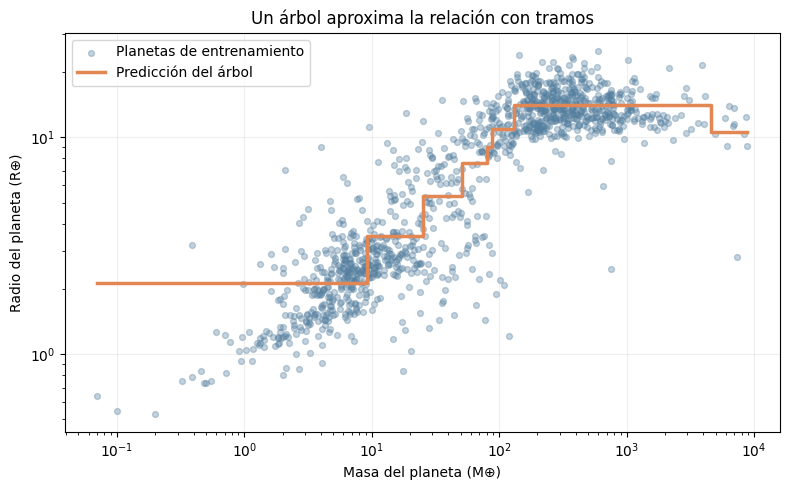

In [17]:
masas_grafica = np.geomspace(
    X_masa_train["pl_bmasse"].min(),
    X_masa_train["pl_bmasse"].max(),
    500,
)
radios_grafica = arbol_masa.predict(
    pd.DataFrame({"pl_bmasse": masas_grafica})
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    X_masa_train["pl_bmasse"],
    y_train,
    s=18,
    alpha=0.35,
    color="#547f9f",
    label="Planetas de entrenamiento",
)
ax.step(
    masas_grafica,
    radios_grafica,
    where="post",
    linewidth=2.5,
    color="#e28654",
    label="Predicción del árbol",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Masa del planeta (M⊕)")
ax.set_ylabel("Radio del planeta (R⊕)")
ax.set_title("Un árbol aproxima la relación con tramos")
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()

### Comparar el error y el coeficiente $R^2$

Evaluamos cada modelo en los mismos $n$ planetas de prueba. $y_i$ es el radio observado, $\hat{y}_i$ la predicción y $\bar{y}_{\mathrm{prueba}}$ el radio promedio observado en ese conjunto.

$$
\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

El **error absoluto medio (MAE)** promedia la distancia entre cada predicción y el radio observado. Se expresa en radios terrestres; un valor menor indica errores típicos más pequeños.

$$
R^2 = 1 -
\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
{\sum_{i=1}^{n}(y_i-\bar{y}_{\mathrm{prueba}})^2}
$$

El **coeficiente de determinación $R^2$** compara los errores cuadrados del modelo con los que resultarían al predecir el promedio del conjunto de prueba. $R^2=1$ indica predicción perfecta; $R^2=0$ iguala esa referencia del promedio; un valor negativo queda por debajo. Este promedio de prueba es la referencia de $R^2$; la línea base **DummyRegressor** predice la mediana calculada en entrenamiento, así que son dos comparaciones distintas.

In [18]:
predicciones = {
    "Mediana": prediccion_base,
    "Árbol: masa": prediccion_arbol,
    "Random Forest: masa": prediccion_masa,
    "Random Forest: masa + insolación": prediccion_masa_insolacion,
}

resultados = pd.DataFrame(
    [
        {
            "Modelo": nombre,
            "MAE (R⊕)": mean_absolute_error(y_test, prediccion),
            "R²": r2_score(y_test, prediccion),
        }
        for nombre, prediccion in predicciones.items()
    ]
).sort_values("MAE (R⊕)")

display(resultados.round(3))

,Modelo,MAE (R⊕),R²
3,Random Forest: masa + insolación,1.191,0.889
2,Random Forest: masa,1.673,0.814
1,Árbol: masa,1.751,0.805
0,Mediana,4.897,-0.003


### ¿Qué tan cerca quedan las predicciones?

Cada punto compara el radio observado con el predicho para un planeta reservado. La diagonal $\hat{y}=y$ marca predicción perfecta: cuanto más cerca cae un punto, menor es su error. Los puntos por encima indican sobreestimación; por debajo, subestimación.

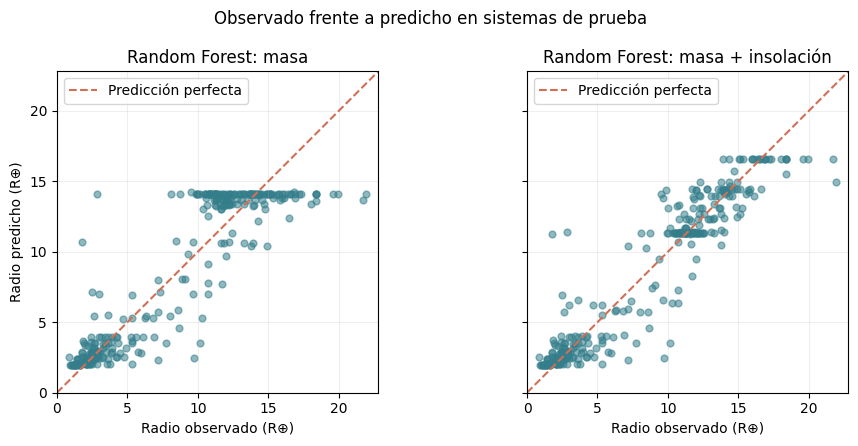

In [19]:
limite_inferior = min(
    y_test.min(),
    prediccion_masa.min(),
    prediccion_masa_insolacion.min(),
)
limite_superior = max(
    y_test.max(),
    prediccion_masa.max(),
    prediccion_masa_insolacion.max(),
)
margen = 0.04 * (limite_superior - limite_inferior)
limites = (limite_inferior - margen, limite_superior + margen)

fig, ejes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
comparaciones = [
    (prediccion_masa, "Random Forest: masa"),
    (prediccion_masa_insolacion, "Random Forest: masa + insolación"),
]

for ax, (prediccion, titulo) in zip(ejes, comparaciones):
    ax.scatter(y_test, prediccion, alpha=0.55, s=24, color="#347e8b")
    ax.plot(limites, limites, "--", color="#d16f55", label="Predicción perfecta")
    ax.set_xlim(limites)
    ax.set_ylim(limites)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Radio observado (R⊕)")
    ax.set_title(titulo)
    ax.grid(alpha=0.2)
    ax.legend()

ejes[0].set_ylabel("Radio predicho (R⊕)")
fig.suptitle("Observado frente a predicho en planetas de prueba")
fig.tight_layout()
plt.show()

### Importancia de características (*feature importance*)

#### ¿Qué calcula este gráfico?

El atributo `feature_importances_` del `RandomForestRegressor` usa la **disminución media de impureza** (MDI): suma cuánto reduce cada predictor el error de los nodos donde se usa para dividir. En estos regresores, el criterio `squared_error` mide la impureza de un nodo mediante el error cuadrático medio (MSE) de los radios que contiene. Algunas referencias llaman *Gini importance* a esta familia de medidas; aquí la impureza concreta es MSE, no Gini.

Para un nodo \(N\), con \(n_N\) planetas y radio medio \(\bar r_N\), la impureza es:

$$I(N)=\frac{1}{n_N}\sum_{i\in N}(r_i-\bar r_N)^2.$$

Si el nodo se divide en los hijos izquierdo y derecho, la reducción de error es:

$$\Delta I(N)=I(N)-\left(\frac{n_L}{n_N}I(N_L)+\frac{n_R}{n_N}I(N_R)\right).$$

En el árbol \(t\), cada reducción se pondera por la fracción de planetas que llega al nodo, \(p_t(N)=n_N/n_{\mathrm{raíz},t}\). Para el predictor \(j\), el árbol suma esas reducciones y normaliza el resultado:

$$A_{j,t}=\sum_{N\in t,\,v(N)=j}p_t(N)\,\Delta I(N),\qquad
\mathrm{FI}_{j,t}=\frac{A_{j,t}}{\sum_k A_{k,t}}.$$

El bosque promedia la importancia de sus \(T\) árboles:

$$\mathrm{FI}_j=\frac{1}{T}\sum_{t=1}^{T}\mathrm{FI}_{j,t},\qquad
\sum_j\mathrm{FI}_j=1.$$

El porcentaje del gráfico indica qué parte de la importancia MDI total corresponde a cada predictor. Se calcula con los datos de entrenamiento, puede favorecer variables con muchos valores posibles de corte y no mide causalidad ni reemplaza el MAE y el \(R^2\) calculados en prueba.


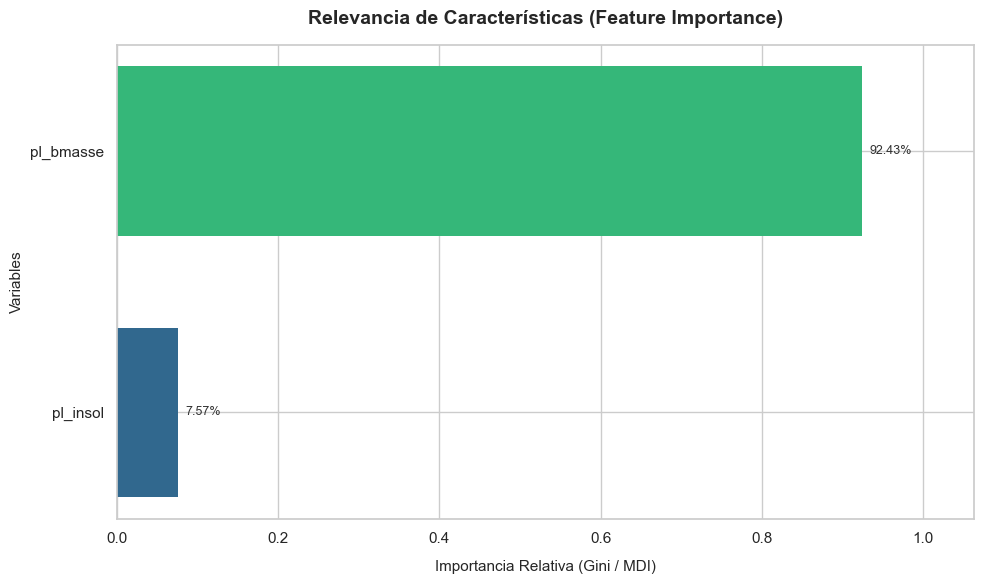

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. EXTRACCIÓN DE LA IMPORTANCIA DE VARIABLES
importancias = bosque_masa_insolacion.feature_importances_

# Crear DataFrame con los resultados
df_importancia = pd.DataFrame({
    'Feature': X_mi_train.columns,
    'Importance': importancias
}).sort_values(by='Importance', ascending=True)  # Ascendente para graficar horizontal

# ==============================================================================
# 2. VISUALIZACIÓN GRÁFICA
# ==============================================================================
plt.figure(figsize=(10, max(6, len(df_importancia) * 0.35)))
sns.set_theme(style="whitegrid")

# Gráfico de barras horizontal con paleta degradada
bars = plt.barh(
    y=df_importancia['Feature'], 
    width=df_importancia['Importance'], 
    color=sns.color_palette("viridis", len(df_importancia)),
    edgecolor="none",
    height=0.65
)

# Añadir etiquetas con el porcentaje numérico en cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (df_importancia['Importance'].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{width * 100:.2f}%",
        va='center',
        ha='left',
        fontsize=9,
        color='#333333',
        fontweight='medium'
    )

plt.title("Importancia de características del bosque (MDI)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Importancia relativa (reducción de MSE / MDI)", fontsize=11, labelpad=10)
plt.ylabel("Variables", fontsize=11)
plt.xlim(0, df_importancia['Importance'].max() * 1.15)  # Espacio para los textos

plt.tight_layout()
plt.show()


Fuentes: [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/), [columnas de PSCompPars](https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html), [cálculos de PSCompPars](https://exoplanetarchive.ipac.caltech.edu/docs/pscp_calc.html), documentación de scikit-learn para [DummyRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html), [árboles de regresión](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html), [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), [RandomForestRegressor e importancia MDI](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) y [MAE y R²](https://scikit-learn.org/stable/modules/model_evaluation.html).

## Volver al cierre de la sesión

En la estación de cierre de S02 puedes comunicar qué mostró la comparación y cuáles son sus límites.

[Volver a la Estación 6 · Cierre: interpretar los resultados](https://d4san.github.io/ML-CPlanetarias/sesiones/s02/?estacion=cierre)
